# CV II Final Project
## Cross-Signer Generalization for Isolated ASL Word Classification on WLASL

Students: Azaliia Agisheva & Jose Manuel Bueno

**LLM Assistance:** LLMs were used for code refactoring and grammatical editing of the report. All research decisions, architecture selection, experiments, analysis, and conclusions were performed by the authors.

## Introduction

Automatic sign language recognition aims to map video of a signer to a linguistic label (here, an isolated ASL gloss). Most public benchmarks, including WLASL, assign clips to train and test splits at the **video** level. Because the same signer often appears in both splits, models can partially succeed by recognizing *who* is signing rather than *what* gloss is performed. That leakage inflates accuracy and hides poor transfer to new performers.

This notebook addresses the **cross-signer generalization** challenge from Domain C of the course brief: can a model trained on some signers classify glosses correctly on **held-out signers** it has never seen? We treat signer overlap as the primary confound and build an evaluation protocol where train, validation, and test partitions are **signer-disjoint**.

**Dataset.** We use WLASL v0.3 with the NSLT-100 label set (100 gloss classes). After restricting to locally available mp4 clips with known `signer_id` metadata, the working corpus contains **1,013 clips** from **64 signers**. Clips are trimmed using NSLT frame ranges. A custom split assigns signers in a fixed round-robin ratio (~70% / 10% / 20%) with repair steps so every class appears in both train and test; the result is **721 / 14 / 278** clips across **45 / 5 / 14** signers respectively (`dataset/splits/signer_disjoint_nslt100.json`).

**Pipeline and architecture.** RGB frames are not fed directly to the classifier. Each clip is passed through **MediaPipe Holistic** to extract 2D body and hand landmarks. Landmarks are converted to SPOTER-compatible CSV sequences, then normalized with the **Boháček signing-space** (head-unit body box) and **per-hand bounding-box** transforms from the SPOTER repository. A **SPOTER** transformer (hidden dim 108, 9 encoder / 6 decoder layers) classifies padded 50-frame pose tensors. Training uses SGD (lr 0.001), batch size 1, data augmentation, and early stopping on validation accuracy (patience 15, seed 379).

**Evaluation protocol.** Primary metrics are **top-1 accuracy** and **macro-F1** on the **14 signer-disjoint test signers only**. Validation (5 signers, 14 clips) is used solely for model selection. We also report majority-class and chance baselines on the same test split. Failure analysis links quantitative errors to two mechanistic hypotheses: cross-signer kinematic shift and fine-grained 2D pose ambiguity.

**Extension.** Motivated by the dominant hand-shape confusions in failure analysis, we optionally apply **Park et al. (2024)** neck–palm anchor translation and bilinear hand keypoint reconstruction before SPOTER normalization, then retrain with identical hyperparameters.

**Objective.** Determine whether a skeleton-only, linguistically motivated pose pipeline improves over trivial baselines on unseen signers, and whether the train–test gap supports or refutes the hypothesis that removing RGB appearance is sufficient for cross-signer gloss recognition.




## 1. Configuration

The next cell sets paths, hyperparameters and output locations. Paths default to Kaggle input/working directories when present, otherwise to the local project root. `USE_PARK_NORM` stays `False` for the main experiment, in the Park extension §14 we enable it

In [1]:
from pathlib import Path

# Kaggle paths (fallback to local project root when not on Kaggle)
DATA_ROOT = Path("/kaggle/input/wlasl-project")
if not DATA_ROOT.exists():
    for candidate in (Path("."), Path(".."), Path("../..")):
        if (candidate / "dataset" / "WLASL_v0.3.json").is_file():
            DATA_ROOT = candidate.resolve()
            break
    else:
        DATA_ROOT = Path(".").resolve()
WORK_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else DATA_ROOT

# Hyperparameters
NUM_CLASSES = 100
HIDDEN_DIM = 108
MAX_FRAMES = 50
EPOCHS = 100
LR = 0.001
BATCH_SIZE = 1
PATIENCE = 15
SEED = 379

# Derived paths
DATASET_DIR = DATA_ROOT / "dataset"
VIDEOS_DIR = DATASET_DIR / "videos"
SPLIT_PATH = DATASET_DIR / "splits" / "signer_disjoint_nslt100.json"
POSE_DIR = WORK_DIR / "dataset" / "poses"
MODEL_PATH = DATA_ROOT / "models" / "holistic_landmarker.task"
OUTPUT_DIR = WORK_DIR / "outputs" / "spoter"

USE_PARK_NORM = False  # set True in §14 for Park (2024) extension
CLASS_LIST_PATH = DATASET_DIR / "wlasl_class_list.txt"
FAILURE_FIG_DIR = OUTPUT_DIR / "failure_cases"
BASELINE_TEST = {"top1_accuracy": 0.10071942446043165, "macro_f1": 0.07392307486115536}


In [2]:
import ctypes, os, subprocess, sys

# WSL2/headless Linux: MediaPipe Tasks API needs libGLESv2.so.2 for initialization.
# Pre-load it with ctypes so the dynamic linker finds it before the mediapipe .so is loaded.
_gles_candidates = [
    os.path.expanduser("~/.local/lib/libGLESv2.so.2"),
    "/snap/gnome-42-2204/226/usr/lib/x86_64-linux-gnu/libGLESv2.so.2",
    "/snap/gnome-42-2204/247/usr/lib/x86_64-linux-gnu/libGLESv2.so.2",
]
for _p in _gles_candidates:
    if os.path.exists(_p):
        try:
            ctypes.CDLL(_p)
            print(f"Pre-loaded {_p}")
        except OSError:
            pass
        break

subprocess.run([
    sys.executable, "-m", "pip", "install", "-q",
    "mediapipe", "opencv-python", "scikit-learn", "tqdm", "matplotlib",
], check=True)

import ast
import copy
import json
import logging
import math
import os
import random
from collections import Counter, defaultdict
from concurrent.futures import ProcessPoolExecutor, as_completed
from pathlib import Path
from random import randrange
from typing import Optional

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as torch_data
from mediapipe import Image, ImageFormat
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.core import base_options as base_options_module
from mediapipe.tasks.python.vision import PoseLandmark
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm import tqdm

logging.basicConfig(level=logging.INFO)
print("Imports OK")


Pre-loaded /home/azaliia/.local/lib/libGLESv2.so.2
Imports OK


## 2. Dataset utilities

Signer-disjoint splitting uses WLASL signer metadata to assign signers to train, validation, and test partitions. The process filters NSLT-100 entries to locally available mp4 files and applies a class-coverage repair step to ensure that every gloss is represented in both the training and test sets

In [3]:
SPLIT_NAMES = ("train", "val", "test")
SPLIT_CYCLE = ("train", "train", "train", "train", "train", "train", "train", "val", "test", "test")


def load_signer_lookup(wlasl_path: Path) -> dict[str, int]:
    with open(wlasl_path, encoding="utf-8") as f:
        data = json.load(f)
    lookup: dict[str, int] = {}
    for entry in data:
        for inst in entry.get("instances", []):
            lookup[inst["video_id"]] = inst["signer_id"]
    return lookup


def load_nslt_entries(nslt_path: Path, videos_dir: Path, signer_lookup: dict[str, int]) -> list[dict]:
    with open(nslt_path, encoding="utf-8") as f:
        nslt = json.load(f)
    entries = []
    for video_id, meta in nslt.items():
        mp4 = videos_dir / f"{video_id}.mp4"
        if not mp4.is_file() or video_id not in signer_lookup:
            continue
        class_idx, start_frame, end_frame = meta["action"]
        entries.append({
            "video_id": video_id,
            "signer_id": signer_lookup[video_id],
            "class_idx": class_idx,
            "start_frame": start_frame,
            "end_frame": end_frame,
            "mp4_path": str(mp4.as_posix()),
        })
    return entries


def assign_signers_round_robin(signers: list[int]) -> dict[int, str]:
    signers_sorted = sorted(signers)
    return {sid: SPLIT_CYCLE[i % len(SPLIT_CYCLE)] for i, sid in enumerate(signers_sorted)}


def clips_by_split(entries: list[dict], signer_split: dict[int, str]) -> dict[str, list[dict]]:
    splits: dict[str, list[dict]] = {k: [] for k in SPLIT_NAMES}
    for entry in entries:
        splits[signer_split[entry["signer_id"]]].append(entry)
    return splits


def signers_for_class(entries: list[dict], class_idx: int) -> set[int]:
    return {entry["signer_id"] for entry in entries if entry["class_idx"] == class_idx}


def repair_class_coverage(entries: list[dict], signer_split: dict[int, str]) -> dict[int, str]:
    signer_split = dict(signer_split)
    all_classes = {entry["class_idx"] for entry in entries}

    def missing_classes(split_name: str) -> set[int]:
        present = {entry["class_idx"] for entry in entries if signer_split[entry["signer_id"]] == split_name}
        return all_classes - present

    for class_idx in sorted(missing_classes("test")):
        moved = False
        for sid in sorted(signers_for_class(entries, class_idx)):
            if signer_split[sid] != "train":
                continue
            train_signers_after = {
                s for s in signers_for_class(entries, class_idx)
                if s != sid and signer_split[s] == "train"
            }
            if not train_signers_after:
                continue
            signer_split[sid] = "test"
            moved = True
            break
        if not moved:
            raise RuntimeError(f"Cannot cover class {class_idx} in test split")

    for class_idx in sorted(missing_classes("train")):
        moved = False
        for sid in sorted(signers_for_class(entries, class_idx)):
            if signer_split[sid] not in ("test", "val"):
                continue
            test_signers_after = {
                s for s in signers_for_class(entries, class_idx)
                if s != sid and signer_split[s] == "test"
            }
            if signer_split[sid] == "test" and not test_signers_after:
                continue
            signer_split[sid] = "train"
            moved = True
            break
        if not moved:
            raise RuntimeError(f"Cannot cover class {class_idx} in train split")
    return signer_split


def validate_split(splits: dict[str, list[dict]], all_classes: set[int]) -> None:
    train_signers = {entry["signer_id"] for entry in splits["train"]}
    val_signers = {entry["signer_id"] for entry in splits["val"]}
    test_signers = {entry["signer_id"] for entry in splits["test"]}
    assert not (train_signers & val_signers), "train/val signer overlap"
    assert not (train_signers & test_signers), "train/test signer overlap"
    assert not (val_signers & test_signers), "val/test signer overlap"
    train_classes = {entry["class_idx"] for entry in splits["train"]}
    test_classes = {entry["class_idx"] for entry in splits["test"]}
    assert train_classes == all_classes, f"train missing: {all_classes - train_classes}"
    assert test_classes == all_classes, f"test missing: {all_classes - test_classes}"


def build_signer_disjoint_split(data_root: Path) -> dict:
    dataset_dir = data_root / "dataset"
    entries = load_nslt_entries(
        dataset_dir / "nslt_100.json",
        dataset_dir / "videos",
        load_signer_lookup(dataset_dir / "WLASL_v0.3.json"),
    )
    signers = sorted({entry["signer_id"] for entry in entries})
    all_classes = {entry["class_idx"] for entry in entries}
    signer_split = assign_signers_round_robin(signers)
    signer_split = repair_class_coverage(entries, signer_split)
    splits = clips_by_split(entries, signer_split)
    validate_split(splits, all_classes)
    stats = {
        "num_signers": {k: len({entry["signer_id"] for entry in splits[k]}) for k in SPLIT_NAMES},
        "num_clips": {k: len(splits[k]) for k in SPLIT_NAMES},
        "classes_in_train": len({entry["class_idx"] for entry in splits["train"]}),
        "classes_in_test": len({entry["class_idx"] for entry in splits["test"]}),
        "total_clips": len(entries),
        "total_signers": len(signers),
    }
    return {
        "protocol": "signer_disjoint",
        "subset": "nslt_100",
        "seed": SEED,
        "split_cycle": list(SPLIT_CYCLE),
        "splits": splits,
        "stats": stats,
    }


def resolve_mp4_paths(split_data: dict, data_root: Path) -> dict:
    """Re-resolve mp4 paths relative to current DATA_ROOT."""
    for split_name in SPLIT_NAMES:
        for entry in split_data["splits"][split_name]:
            entry["mp4_path"] = str((data_root / "dataset" / "videos" / f"{entry['video_id']}.mp4").as_posix())
    return split_data


## 3. Dataset loading

We load `WLASL_v0.3.json` and `nslt_100.json`, join signer IDs to NSLT entries, and keep only clips whose mp4 files exist on disk. The printed counts confirm how many glosses, labelled entries and usable clips enter the experiment.

In [4]:
WLASL_PATH = DATASET_DIR / "WLASL_v0.3.json"
NSLT_PATH = DATASET_DIR / "nslt_100.json"

signer_lookup = load_signer_lookup(WLASL_PATH)
local_entries = load_nslt_entries(NSLT_PATH, VIDEOS_DIR, signer_lookup)

with open(WLASL_PATH, encoding="utf-8") as f:
    wlasl_data = json.load(f)
with open(NSLT_PATH, encoding="utf-8") as f:
    nslt_data = json.load(f)

print(f"WLASL glosses: {len(wlasl_data)}")
print(f"NSLT-100 entries: {len(nslt_data)}")
print(f"Local mp4 clips with signer ID: {len(local_entries)}")
print(f"Unique signers: {len({entry['signer_id'] for entry in local_entries})}")
print(f"Unique classes: {len({entry['class_idx'] for entry in local_entries})}")


WLASL glosses: 2000
NSLT-100 entries: 2038
Local mp4 clips with signer ID: 1013
Unique signers: 64
Unique classes: 100


## 4. Dataset analysis

Before splitting, we summarize class and signer imbalance and the distribution of clip lengths. The bar chart shows clips per class index for the 1,013 local clips, most classes have roughly 5–16 examples, which sets expectations for per-class recall on a 100-way task.

Dataset summary
Total clips: 1013
Classes: 100 (range 0–99)
Signers: 64
Clips per class - min: 5, max: 16, mean: 10.1
Clips per signer - min: 1, max: 164, mean: 15.8
Frame span - min: 20, max: 203, median: 59


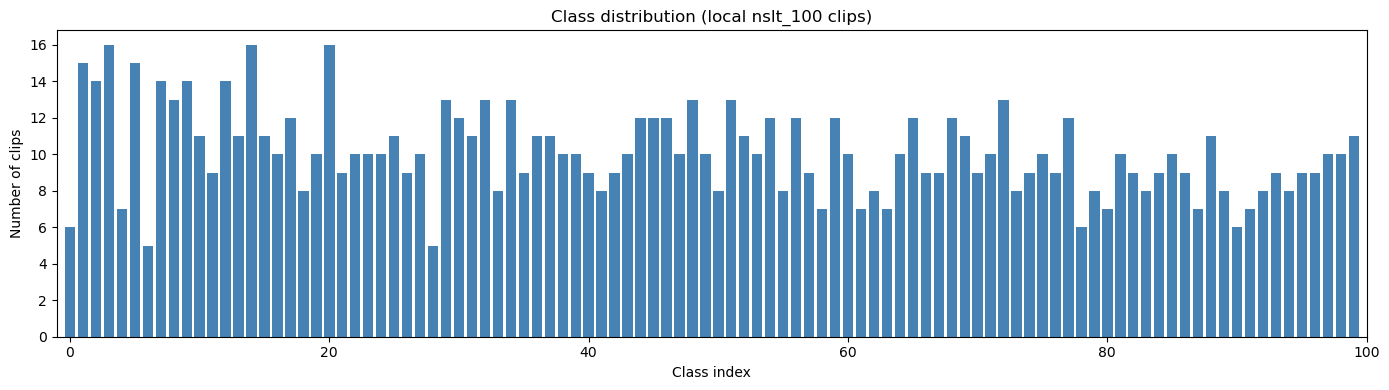

In [5]:
class_counts = Counter(entry["class_idx"] for entry in local_entries)
signer_counts = Counter(entry["signer_id"] for entry in local_entries)
frame_lengths = []
for entry in local_entries:
    end = entry["end_frame"] if entry["end_frame"] >= 0 else 50
    frame_lengths.append(max(1, end - max(1, entry["start_frame"]) + 1))

print("Dataset summary")
print(f"Total clips: {len(local_entries)}")
print(f"Classes: {len(class_counts)} (range {min(class_counts)}–{max(class_counts.keys())})")
print(f"Signers: {len(signer_counts)}")
print(f"Clips per class - min: {min(class_counts.values())}, max: {max(class_counts.values())}, "
      f"mean: {np.mean(list(class_counts.values())):.1f}")
print(f"Clips per signer - min: {min(signer_counts.values())}, max: {max(signer_counts.values())}, "
      f"mean: {np.mean(list(signer_counts.values())):.1f}")
print(f"Frame span - min: {min(frame_lengths)}, max: {max(frame_lengths)}, "
      f"median: {np.median(frame_lengths):.0f}")

fig, ax = plt.subplots(figsize=(14, 4))
classes_sorted = sorted(class_counts.keys())
counts = [class_counts[c] for c in classes_sorted]
ax.bar(classes_sorted, counts, width=0.8, color="steelblue", edgecolor="none")
ax.set_xlabel("Class index")
ax.set_ylabel("Number of clips")
ax.set_title("Class distribution (local nslt_100 clips)")
ax.set_xlim(-1, 100)
plt.tight_layout()
plt.show()


## 5. Train / validation / test split

If `signer_disjoint_nslt100.json` already exists, we load it. Otherwise we build the split with the helpers above and save it. Mp4 paths are re-resolved against the current `DATA_ROOT`. The printed stats verify signer counts and that all 100 classes appear in both train and test.

In [6]:
if SPLIT_PATH.is_file():
    print(f"Loading existing split: {SPLIT_PATH}")
    with open(SPLIT_PATH, encoding="utf-8") as f:
        split_data = json.load(f)
else:
    print("Building signer-disjoint split...")
    split_data = build_signer_disjoint_split(DATA_ROOT)
    SPLIT_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(SPLIT_PATH, "w", encoding="utf-8") as f:
        json.dump(split_data, f, indent=2)
    print(f"Saved split to {SPLIT_PATH}")

split_data = resolve_mp4_paths(split_data, DATA_ROOT)
print("Split stats:", json.dumps(split_data["stats"], indent=2))


Loading existing split: /home/azaliia/projects/CV2/part2/project2/dataset/splits/signer_disjoint_nslt100.json
Split stats: {
  "num_signers": {
    "train": 45,
    "val": 5,
    "test": 14
  },
  "num_clips": {
    "train": 721,
    "val": 14,
    "test": 278
  },
  "classes_in_train": 100,
  "classes_in_test": 100,
  "total_clips": 1013,
  "total_signers": 64
}


## 6. Preprocessing (pose extraction)

MediaPipe Holistic runs in video mode on trimmed clip frames. Body and hand landmarks are written in SPOTER CSV format(list columns per joint). Optional Park preprocessing (`apply_park_preprocessing`) can run at extraction time when `USE_PARK_NORM` is enabled. This cell defines joint names, the landmarker wrapper, and export helpers only - it does not extract poses yet.

In [9]:
BODY_JOINTS = [
    "nose", "neck", "rightEye", "leftEye", "rightEar", "leftEar",
    "rightShoulder", "leftShoulder", "rightElbow", "leftElbow", "rightWrist", "leftWrist",
]
HAND_JOINTS = [
    "wrist", "indexTip", "indexDIP", "indexPIP", "indexMCP",
    "middleTip", "middleDIP", "middlePIP", "middleMCP",
    "ringTip", "ringDIP", "ringPIP", "ringMCP",
    "littleTip", "littleDIP", "littlePIP", "littleMCP",
    "thumbTip", "thumbIP", "thumbMP", "thumbCMC",
]
MP_HAND_TO_SPOTER = {
    0: "wrist", 8: "indexTip", 7: "indexDIP", 6: "indexPIP", 5: "indexMCP",
    12: "middleTip", 11: "middleDIP", 10: "middlePIP", 9: "middleMCP",
    16: "ringTip", 15: "ringDIP", 14: "ringPIP", 13: "ringMCP",
    20: "littleTip", 19: "littleDIP", 18: "littlePIP", 17: "littleMCP",
    4: "thumbTip", 3: "thumbIP", 2: "thumbMP", 1: "thumbCMC",
}


def create_holistic(model_path: Path) -> vision.HolisticLandmarker:
    options = vision.HolisticLandmarkerOptions(
        base_options=base_options_module.BaseOptions(model_asset_path=str(model_path)),
        running_mode=vision.RunningMode.VIDEO,
    )
    return vision.HolisticLandmarker.create_from_options(options)


def pose_point(landmarks, idx: PoseLandmark) -> tuple[float, float]:
    if not landmarks:
        return 0.0, 0.0
    lm = landmarks[idx.value]
    if lm.visibility is not None and lm.visibility < 0.5:
        return 0.0, 0.0
    return lm.x, lm.y


def extract_sequence(entry: dict, model_path: Path) -> dict[str, list[list[float]]]:
    landmarker = create_holistic(model_path)
    try:
        return _extract_sequence_frames(entry, landmarker)
    finally:
        landmarker.close()


def _extract_sequence_frames(entry: dict, landmarker: vision.HolisticLandmarker) -> dict[str, list[list[float]]]:
    cap = cv2.VideoCapture(entry["mp4_path"])
    if not cap.isOpened():
        raise RuntimeError(f"Cannot open {entry['mp4_path']}")
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    start = max(1, int(entry["start_frame"]))
    end = int(entry["end_frame"])
    if end < 0:
        end = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    keys = BODY_JOINTS + [f"{j}_{h}" for h in (0, 1) for j in HAND_JOINTS]
    seq = {k: [] for k in keys}
    frame_idx = 0
    processed_idx = 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frame_idx += 1
        if frame_idx < start:
            continue
        if frame_idx > end:
            break
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = Image(image_format=ImageFormat.SRGB, data=rgb)
        timestamp_ms = int(processed_idx * (1000.0 / fps))
        processed_idx += 1
        result = landmarker.detect_for_video(mp_image, timestamp_ms)
        pose = result.pose_landmarks if result.pose_landmarks else None
        nose = pose_point(pose, PoseLandmark.NOSE)
        le = pose_point(pose, PoseLandmark.LEFT_EYE)
        re = pose_point(pose, PoseLandmark.RIGHT_EYE)
        lsh = pose_point(pose, PoseLandmark.LEFT_SHOULDER)
        rsh = pose_point(pose, PoseLandmark.RIGHT_SHOULDER)
        neck = (
            (lsh[0] + rsh[0]) / 2 if lsh[0] and rsh[0] else 0.0,
            (lsh[1] + rsh[1]) / 2 if lsh[1] and rsh[1] else 0.0,
        )
        body_map = {
            "nose": nose, "neck": neck, "rightEye": re, "leftEye": le,
            "rightEar": pose_point(pose, PoseLandmark.RIGHT_EAR),
            "leftEar": pose_point(pose, PoseLandmark.LEFT_EAR),
            "rightShoulder": rsh, "leftShoulder": lsh,
            "rightElbow": pose_point(pose, PoseLandmark.RIGHT_ELBOW),
            "leftElbow": pose_point(pose, PoseLandmark.LEFT_ELBOW),
            "rightWrist": pose_point(pose, PoseLandmark.RIGHT_WRIST),
            "leftWrist": pose_point(pose, PoseLandmark.LEFT_WRIST),
        }
        for name in BODY_JOINTS:
            x, y = body_map[name]
            seq[name].append([x, y])
        hand_sets = ((0, result.left_hand_landmarks), (1, result.right_hand_landmarks))
        for hand_idx, hand in hand_sets:
            frame_hands = {j: [0.0, 0.0] for j in HAND_JOINTS}
            if hand:
                for mp_idx, spoter_name in MP_HAND_TO_SPOTER.items():
                    lm = hand[mp_idx]
                    frame_hands[spoter_name] = [lm.x, lm.y]
            for j in HAND_JOINTS:
                seq[f"{j}_{hand_idx}"].append(frame_hands[j])
    cap.release()
    if not seq["nose"]:
        raise RuntimeError(f"No frames extracted for {entry['video_id']}")
    return seq


def sequence_to_row(entry: dict, seq: dict[str, list[list[float]]]) -> dict:
    row = {"video_id": entry.get("video_id", ""), "labels": entry["class_idx"] + 1}
    for key, frames in seq.items():
        row[f"{key}_X"] = str([p[0] for p in frames])
        row[f"{key}_Y"] = str([p[1] for p in frames])
    return row



def _is_zero(pt):
    return pt[0] == 0.0 and pt[1] == 0.0


def reconstruct_hand_bilinear(hand_joints: dict[str, list[float]]) -> dict[str, list[float]]:
    """Bilinear reconstruction of missing MediaPipe hand keypoints (Park et al. 2024 idea)."""
    out = dict(hand_joints)
    chain = [
        ("wrist", "indexMCP", "indexPIP", "indexDIP", "indexTip"),
        ("wrist", "middleMCP", "middlePIP", "middleDIP", "middleTip"),
        ("wrist", "ringMCP", "ringPIP", "ringDIP", "ringTip"),
        ("wrist", "littleMCP", "littlePIP", "littleDIP", "littleTip"),
        ("wrist", "thumbCMC", "thumbMP", "thumbIP", "thumbTip"),
    ]
    for finger in chain:
        present = [j for j in finger if not _is_zero(out[j])]
        if len(present) < 2:
            continue
        for j in finger:
            if not _is_zero(out[j]):
                continue
            idx = finger.index(j)
            left = next((finger[k] for k in range(idx - 1, -1, -1) if not _is_zero(out[finger[k]])), None)
            right = next((finger[k] for k in range(idx + 1, len(finger)) if not _is_zero(out[finger[k]])), None)
            if left and right:
                li, ri = finger.index(left), finger.index(right)
                t = (idx - li) / (ri - li)
                out[j] = (
                    out[left][0] + t * (out[right][0] - out[left][0]),
                    out[left][1] + t * (out[right][1] - out[left][1]),
                )
            elif left:
                li = finger.index(left)
                if li > 0 and not _is_zero(out[finger[li - 1]]):
                    prev = finger[li - 1]
                    out[j] = (2 * out[left][0] - out[prev][0], 2 * out[left][1] - out[prev][1])
            elif right:
                ri = finger.index(right)
                if ri + 1 < len(finger) and not _is_zero(out[finger[ri + 1]]):
                    nxt = finger[ri + 1]
                    out[j] = (2 * out[right][0] - out[nxt][0], 2 * out[right][1] - out[nxt][1])
    return out


def apply_park_preprocessing(seq: dict[str, list[list[float]]]) -> dict[str, list[list[float]]]:
    """Neck/palm anchor translation + bilinear hand reconstruction before SPOTER normalization."""
    out = {k: [p[:] for p in v] for k, v in seq.items()}
    n_frames = len(out["nose"])
    for t in range(n_frames):
        for hand_idx in (0, 1):
            prefix = f"_{hand_idx}"
            hand = {j: tuple(out[f"{j}{prefix}"][t]) for j in HAND_JOINTS}
            hand = reconstruct_hand_bilinear(hand)
            wrist = hand["wrist"]
            mcp_keys = [f"{j}{prefix}" for j in ("indexMCP", "middleMCP", "ringMCP", "littleMCP")]
            mcps = [hand[j.replace(prefix, "")] for j in mcp_keys if not _is_zero(hand[j.replace(prefix, "")])]
            if mcps:
                palm = (sum(p[0] for p in mcps) / len(mcps), sum(p[1] for p in mcps) / len(mcps))
            else:
                palm = wrist
            neck = tuple(out["neck"][t])
            if not _is_zero(neck) and not _is_zero(palm):
                dx, dy = neck[0] - palm[0], neck[1] - palm[1]
                for j in HAND_JOINTS:
                    key = f"{j}{prefix}"
                    if not _is_zero(hand[j]):
                        out[key][t] = [hand[j][0] + dx, hand[j][1] + dy]
    return out



def process_one_entry(entry: dict, cache_dir: Path, model_path: Path) -> tuple[dict, dict]:
    cache_file = cache_dir / f"{entry['video_id']}.npy"
    if cache_file.is_file():
        seq = np.load(cache_file, allow_pickle=True).item()
    else:
        seq = extract_sequence(entry, model_path)
        if USE_PARK_NORM:
            seq = apply_park_preprocessing(seq)
        np.save(cache_file, seq, allow_pickle=True)
    return sequence_to_row(entry, seq), entry


def export_split_csv(split_name: str, entries: list[dict], out_path: Path,
                     cache_dir: Path, model_path: Path, workers: int = 1) -> None:
    rows = []
    cache_dir.mkdir(parents=True, exist_ok=True)
    if workers <= 1:
        for entry in tqdm(entries, desc=f"poses-{split_name}"):
            row, _ = process_one_entry(entry, cache_dir, model_path)
            rows.append(row)
    else:
        with ProcessPoolExecutor(max_workers=workers) as pool:
            futures = [pool.submit(process_one_entry, entry, cache_dir, model_path) for entry in entries]
            for fut in tqdm(as_completed(futures), total=len(futures), desc=f"poses-{split_name}"):
                row, _ = fut.result()
                rows.append(row)
    df = pd.DataFrame(rows)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(out_path, index=False)
    print(f"Wrote {out_path} ({len(df)} clips)")


def csv_row_to_sequence(row) -> dict[str, list[list[float]]]:
    """Reconstruct raw pose sequence dict from a SPOTER CSV row."""
    keys = BODY_JOINTS + [f"{j}_{h}" for h in (0, 1) for j in HAND_JOINTS]
    seq = {}
    for key in keys:
        xs = ast.literal_eval(row[f"{key}_X"])
        ys = ast.literal_eval(row[f"{key}_Y"])
        seq[key] = [[float(x), float(y)] for x, y in zip(xs, ys)]
    return seq


def build_park_csvs_from_baseline(baseline_dir: Path, out_dir: Path, split_data: dict) -> None:
    """Derive Park-normalized pose CSVs from existing baseline CSVs (no MediaPipe re-run)."""
    out_dir.mkdir(parents=True, exist_ok=True)
    cache_dir = out_dir / "cache"
    cache_dir.mkdir(parents=True, exist_ok=True)
    for split_name in SPLIT_NAMES:
        baseline_csv = baseline_dir / f"{split_name}.csv"
        entries = split_data["splits"][split_name]
        df = pd.read_csv(baseline_csv, dtype={"video_id": str}, encoding="utf-8")
        rows = []
        for i, (_, row) in enumerate(df.iterrows()):
            seq = csv_row_to_sequence(row)
            seq = apply_park_preprocessing(seq)
            if i < len(entries):
                np.save(cache_dir / f"{entries[i]['video_id']}.npy", seq, allow_pickle=True)
            vid = row.get("video_id", entries[i]["video_id"] if i < len(entries) else "")
            rows.append(sequence_to_row({"video_id": vid, "class_idx": int(row["labels"]) - 1}, seq))
        out_path = out_dir / f"{split_name}.csv"
        pd.DataFrame(rows).to_csv(out_path, index=False)
        print(f"Wrote {out_path} ({len(rows)} clips) from baseline + Park preprocessing")



### Resolve or extract pose CSV files

This cell checks for precomputed `train.csv`, `val.csv`, and `test.csv` under POSE_DIR. If they exist, extraction is skipped. Otherwise MediaPipe processes each split (cached per video as `.npy` files).

In [10]:
if USE_PARK_NORM:
    POSE_DIR = WORK_DIR / "dataset" / "poses_park"

input_pose_dir = DATA_ROOT / "dataset" / ("poses_park" if USE_PARK_NORM else "poses")
if all((input_pose_dir / f"{s}.csv").is_file() for s in SPLIT_NAMES) and not (POSE_DIR / "train.csv").is_file():
    POSE_DIR = input_pose_dir

train_csv = POSE_DIR / "train.csv"
val_csv = POSE_DIR / "val.csv"
test_csv = POSE_DIR / "test.csv"

if train_csv.is_file() and val_csv.is_file() and test_csv.is_file():
    print(f"Using precomputed pose CSVs in {POSE_DIR}")
    # Alignment check: verify that every CSV row's label matches the split entry for that video.
    _test_df = pd.read_csv(test_csv, dtype={"video_id": str}, usecols=lambda c: c in ["video_id", "labels"])
    if "video_id" in _test_df.columns:
        _entry_map = {e["video_id"]: e["class_idx"] for e in split_data["splits"]["test"]}
        _bad = sum(
            int(row["labels"]) - 1 != _entry_map.get(str(row["video_id"]), -1)
            for _, row in _test_df.iterrows()
        )
        assert _bad == 0, (
            f"Pose CSV labels misaligned with split on {_bad}/{len(_test_df)} test rows. "
            "Delete dataset/poses/ and re-run this cell to regenerate aligned CSVs."
        )
        print("Pose CSV alignment check passed.")
    else:
        print("WARNING: pose CSVs have no video_id column — alignment cannot be verified.")
else:
    print("Extracting poses with MediaPipe Holistic...")
    cache_dir = POSE_DIR / "cache"
    for split_name in SPLIT_NAMES:
        export_split_csv(
            split_name,
            split_data["splits"][split_name],
            POSE_DIR / f"{split_name}.csv",
            cache_dir,
            MODEL_PATH,
            workers=1,
        )
print(f"Pose CSVs ready: train={train_csv.is_file()}, val={val_csv.is_file()}, test={test_csv.is_file()}")


Using precomputed pose CSVs in /home/azaliia/projects/CV2/part2/project2/dataset/poses
Pose CSV alignment check passed.
Pose CSVs ready: train=True, val=True, test=True


## 7. Baseline models

Before training SPOTER, we establish trivial predictors on the same signer-disjoint test labels: always predicting the training-set majority class (class 5) and the chance rate for uniform random guessing over 100 classes. These numbers anchor how much lift the pose model must provide.

In [11]:
test_labels = [e["class_idx"] for e in split_data["splits"]["test"]]
train_labels = [e["class_idx"] for e in split_data["splits"]["train"]]
majority_class = Counter(train_labels).most_common(1)[0][0]

y_true_base = np.array(test_labels)
y_pred_majority = np.full_like(y_true_base, majority_class)
majority_acc = accuracy_score(y_true_base, y_pred_majority)
majority_f1 = f1_score(y_true_base, y_pred_majority, average="macro")

chance_acc = 1.0 / NUM_CLASSES
chance_f1 = 1.0 / NUM_CLASSES  # expected macro-F1 under uniform random

print("Baselines (test split)")
print(f"Majority class ({majority_class}): top-1={majority_acc:.4f}, macro-F1={majority_f1:.4f}")
print(f"Chance (1/{NUM_CLASSES}):          top-1={chance_acc:.4f}, macro-F1={chance_f1:.4f}")

Baselines (test split)
Majority class (5): top-1=0.0036, macro-F1=0.0001
Chance (1/100):          top-1=0.0100, macro-F1=0.0100


## 8. SPOTER model - normalization and augmentation

SPOTER expects pose sequences normalized into a signing space (Boháček et al.) rather than raw MediaPipe coordinates. The first block defines body and hand normalization on dictionary-form landmarks. The second block adds training-time augmentations (rotation, shear, arm joint rotation) matching the reference SPOTER training recipe.

In [12]:
def normalize_single_body_dict(row: dict):
    """Normalize body pose skeletal data (Bohacek algorithm, dict form)."""
    sequence_size = len(row["leftEar"])
    valid_sequence = True
    original_row = row
    last_starting_point, last_ending_point = None, None

    for sequence_index in range(sequence_size):
        if (row["leftShoulder"][sequence_index][0] == 0 or row["rightShoulder"][sequence_index][0] == 0) and (
                row["neck"][sequence_index][0] == 0 or row["nose"][sequence_index][0] == 0):
            if not last_starting_point:
                valid_sequence = False
                continue
            starting_point, ending_point = last_starting_point, last_ending_point
        else:
            if row["leftShoulder"][sequence_index][0] != 0 and row["rightShoulder"][sequence_index][0] != 0:
                ls = (row["leftShoulder"][sequence_index][0], row["leftShoulder"][sequence_index][1])
                rs = (row["rightShoulder"][sequence_index][0], row["rightShoulder"][sequence_index][1])
                head_metric = ((((ls[0] - rs[0]) ** 2) + ((ls[1] - rs[1]) ** 2)) ** 0.5)
            else:
                neck = (row["neck"][sequence_index][0], row["neck"][sequence_index][1])
                nose = (row["nose"][sequence_index][0], row["nose"][sequence_index][1])
                head_metric = ((((neck[0] - nose[0]) ** 2) + ((neck[1] - nose[1]) ** 2)) ** 0.5)

            starting_point = [row["neck"][sequence_index][0] - 3 * head_metric,
                              row["leftEye"][sequence_index][1] + head_metric]
            ending_point = [row["neck"][sequence_index][0] + 3 * head_metric, starting_point[1] - 6 * head_metric]
            last_starting_point, last_ending_point = starting_point, ending_point

        if starting_point[0] < 0: starting_point[0] = 0
        if starting_point[1] < 0: starting_point[1] = 0
        if ending_point[0] < 0: ending_point[0] = 0
        if ending_point[1] < 0: ending_point[1] = 0

        for identifier in BODY_JOINTS:
            key = identifier
            if row[key][sequence_index][0] == 0:
                continue
            if (ending_point[0] - starting_point[0]) == 0 or (starting_point[1] - ending_point[1]) == 0:
                valid_sequence = False
                break
            row[key][sequence_index] = list(row[key][sequence_index])
            row[key][sequence_index][0] = (row[key][sequence_index][0] - starting_point[0]) / (ending_point[0] - starting_point[0])
            row[key][sequence_index][1] = (row[key][sequence_index][1] - ending_point[1]) / (starting_point[1] - ending_point[1])

    return row if valid_sequence else original_row


def normalize_single_hand_dict(row: dict):
    """Normalize hand pose skeletal data (Bohacek algorithm, dict form)."""
    hand_landmarks = {0: [], 1: []}
    num_hands = 2 if "wrist_1" in row.keys() else 1

    for identifier in HAND_JOINTS:
        for hand_index in range(num_hands):
            hand_landmarks[hand_index].append(identifier + "_" + str(hand_index))

    for hand_index in range(num_hands):
        sequence_size = len(row["wrist_" + str(hand_index)])
        for sequence_index in range(sequence_size):
            landmarks_x_values = [row[key][sequence_index][0] for key in hand_landmarks[hand_index]
                                  if row[key][sequence_index][0] != 0]
            landmarks_y_values = [row[key][sequence_index][1] for key in hand_landmarks[hand_index]
                                  if row[key][sequence_index][1] != 0]
            if not landmarks_x_values or not landmarks_y_values:
                continue

            width = max(landmarks_x_values) - min(landmarks_x_values)
            height = max(landmarks_y_values) - min(landmarks_y_values)
            if width > height:
                delta_x = 0.1 * width
                delta_y = delta_x + ((width - height) / 2)
            else:
                delta_y = 0.1 * height
                delta_x = delta_y + ((height - width) / 2)

            starting_point = (min(landmarks_x_values) - delta_x, min(landmarks_y_values) - delta_y)
            ending_point = (max(landmarks_x_values) + delta_x, max(landmarks_y_values) + delta_y)

            for identifier in HAND_JOINTS:
                key = identifier + "_" + str(hand_index)
                if row[key][sequence_index][0] == 0 or (ending_point[0] - starting_point[0]) == 0 or (
                        starting_point[1] - ending_point[1]) == 0:
                    continue
                row[key][sequence_index] = list(row[key][sequence_index])
                row[key][sequence_index][0] = (row[key][sequence_index][0] - starting_point[0]) / (ending_point[0] - starting_point[0])
                row[key][sequence_index][1] = (row[key][sequence_index][1] - starting_point[1]) / (ending_point[1] - starting_point[1])

    return row

HAND_LANDMARK_KEYS = [id + "_0" for id in HAND_JOINTS] + [id + "_1" for id in HAND_JOINTS]
ARM_IDENTIFIERS_ORDER = ["neck", "$side$Shoulder", "$side$Elbow", "$side$Wrist"]


def __random_pass(prob):
    return random.random() < prob


def __numpy_to_dictionary(data_array: np.ndarray) -> dict:
    output = {}
    for landmark_index, identifier in enumerate(BODY_JOINTS):
        output[identifier] = data_array[:, landmark_index].tolist()
    return output


def __dictionary_to_numpy(landmarks_dict: dict) -> np.ndarray:
    output = np.empty(shape=(len(landmarks_dict["leftEar"]), len(BODY_JOINTS), 2))
    for landmark_index, identifier in enumerate(BODY_JOINTS):
        output[:, landmark_index, 0] = np.array(landmarks_dict[identifier])[:, 0]
        output[:, landmark_index, 1] = np.array(landmarks_dict[identifier])[:, 1]
    return output


def __rotate(origin: tuple, point: tuple, angle: float):
    ox, oy = origin
    px, py = point
    qx = ox + math.cos(angle) * (px - ox) - math.sin(angle) * (py - oy)
    qy = oy + math.sin(angle) * (px - ox) + math.cos(angle) * (py - oy)
    return qx, qy


def __preprocess_row_sign(sign: dict) -> tuple:
    sign_eval = sign
    if "nose_X" in sign_eval:
        body_landmarks = {identifier: [(x, y) for x, y in zip(sign_eval[identifier + "_X"], sign_eval[identifier + "_Y"])]
                          for identifier in BODY_JOINTS}
        hand_landmarks = {identifier: [(x, y) for x, y in zip(sign_eval[identifier + "_X"], sign_eval[identifier + "_Y"])]
                          for identifier in HAND_LANDMARK_KEYS}
    else:
        body_landmarks = {identifier: sign_eval[identifier] for identifier in BODY_JOINTS}
        hand_landmarks = {identifier: sign_eval[identifier] for identifier in HAND_LANDMARK_KEYS}
    return body_landmarks, hand_landmarks


def __wrap_sign_into_row(body_identifiers: dict, hand_identifiers: dict) -> dict:
    return {**body_identifiers, **hand_identifiers}


def augment_rotate(sign: dict, angle_range: tuple) -> dict:
    body_landmarks, hand_landmarks = __preprocess_row_sign(sign)
    angle = math.radians(random.uniform(*angle_range))
    body_landmarks = {key: [__rotate((0.5, 0.5), frame, angle) for frame in value]
                      for key, value in body_landmarks.items()}
    hand_landmarks = {key: [__rotate((0.5, 0.5), frame, angle) for frame in value]
                      for key, value in hand_landmarks.items()}
    return __wrap_sign_into_row(body_landmarks, hand_landmarks)


def augment_shear(sign: dict, type: str, squeeze_ratio: tuple) -> dict:
    body_landmarks, hand_landmarks = __preprocess_row_sign(sign)
    if type == "squeeze":
        move_left = random.uniform(*squeeze_ratio)
        move_right = random.uniform(*squeeze_ratio)
        src = np.array(((0, 1), (1, 1), (0, 0), (1, 0)), dtype=np.float32)
        dest = np.array(((0 + move_left, 1), (1 - move_right, 1), (0 + move_left, 0), (1 - move_right, 0)),
                        dtype=np.float32)
        mtx = cv2.getPerspectiveTransform(src, dest)
    elif type == "perspective":
        move_ratio = random.uniform(*squeeze_ratio)
        src = np.array(((0, 1), (1, 1), (0, 0), (1, 0)), dtype=np.float32)
        if __random_pass(0.5):
            dest = np.array(((0 + move_ratio, 1 - move_ratio), (1, 1), (0 + move_ratio, 0 + move_ratio), (1, 0)),
                            dtype=np.float32)
        else:
            dest = np.array(((0, 1), (1 - move_ratio, 1 - move_ratio), (0, 0), (1 - move_ratio, 0 + move_ratio)),
                            dtype=np.float32)
        mtx = cv2.getPerspectiveTransform(src, dest)
    else:
        logging.error("Unsupported shear type provided.")
        return {}

    landmarks_array = __dictionary_to_numpy(body_landmarks)
    augmented_landmarks = cv2.perspectiveTransform(np.array(landmarks_array, dtype=np.float32), mtx)
    augmented_zero_landmark = cv2.perspectiveTransform(np.array([[[0, 0]]], dtype=np.float32), mtx)[0][0]
    augmented_landmarks = np.stack([np.where(sub == augmented_zero_landmark, [0, 0], sub) for sub in augmented_landmarks])
    body_landmarks = __numpy_to_dictionary(augmented_landmarks)
    return __wrap_sign_into_row(body_landmarks, hand_landmarks)


def augment_arm_joint_rotate(sign: dict, probability: float, angle_range: tuple) -> dict:
    body_landmarks, hand_landmarks = __preprocess_row_sign(sign)
    for side in ["left", "right"]:
        for landmark_index, landmark_origin in enumerate(ARM_IDENTIFIERS_ORDER):
            landmark_origin = landmark_origin.replace("$side$", side)
            if landmark_origin not in body_landmarks:
                break
            if __random_pass(probability):
                angle = math.radians(random.uniform(*angle_range))
                for to_be_rotated in ARM_IDENTIFIERS_ORDER[landmark_index + 1:]:
                    to_be_rotated = to_be_rotated.replace("$side$", side)
                    if to_be_rotated not in body_landmarks:
                        continue
                    body_landmarks[to_be_rotated] = [
                        __rotate(body_landmarks[landmark_origin][frame_index], frame, angle)
                        for frame_index, frame in enumerate(body_landmarks[to_be_rotated])
                    ]
    return __wrap_sign_into_row(body_landmarks, hand_landmarks)

### Dataset class, input noise, and tensor conversion

`CzechSLRDataset` reads pose CSVs, optionally applies augmentations and normalization, and returns tensors centered at 0.5. `GaussianNoise` adds small isotropic jitter during training. `HAND_LANDMARK_KEYS` lists both hands in the column order expected by the loader.

In [13]:
class GaussianNoise(object):
    def __init__(self, mean=0., std=1.):
        self.std = std
        self.mean = mean

    def __call__(self, tensor):
        return tensor + torch.randn(tensor.size()) * self.std + self.mean

    def __repr__(self):
        return self.__class__.__name__ + f'(mean={self.mean}, std={self.std})'

def load_dataset(file_location: str):
    df = pd.read_csv(file_location, dtype={"video_id": str}, encoding="utf-8")
    df.columns = [item.replace("_left_", "_0_").replace("_right_", "_1_") for item in list(df.columns)]
    if "neck_X" not in df.columns:
        df["neck_X"] = [0 for _ in range(df.shape[0])]
        df["neck_Y"] = [0 for _ in range(df.shape[0])]

    labels = df["labels"].to_list()
    data = []
    for _, row in df.iterrows():
        current_row = np.empty(shape=(len(ast.literal_eval(row["leftEar_X"])),
                                      len(BODY_JOINTS + HAND_LANDMARK_KEYS), 2))
        for index, identifier in enumerate(BODY_JOINTS + HAND_LANDMARK_KEYS):
            current_row[:, index, 0] = ast.literal_eval(row[identifier + "_X"])
            current_row[:, index, 1] = ast.literal_eval(row[identifier + "_Y"])
        data.append(current_row)
    return data, labels


def tensor_to_dictionary(landmarks_tensor: torch.Tensor) -> dict:
    data_array = landmarks_tensor.numpy()
    output = {}
    for landmark_index, identifier in enumerate(BODY_JOINTS + HAND_LANDMARK_KEYS):
        output[identifier] = data_array[:, landmark_index]
    return output


def dictionary_to_tensor(landmarks_dict: dict) -> torch.Tensor:
    output = np.empty(shape=(len(landmarks_dict["leftEar"]), len(BODY_JOINTS + HAND_LANDMARK_KEYS), 2))
    for landmark_index, identifier in enumerate(BODY_JOINTS + HAND_LANDMARK_KEYS):
        output[:, landmark_index, 0] = [frame[0] for frame in landmarks_dict[identifier]]
        output[:, landmark_index, 1] = [frame[1] for frame in landmarks_dict[identifier]]
    return torch.from_numpy(output)


class CzechSLRDataset(torch_data.Dataset):
    def __init__(self, dataset_filename: str, num_labels=5, transform=None, augmentations=False,
                 augmentations_prob=0.5, normalize=True):
        data, labels = load_dataset(dataset_filename)
        self.data = data
        self.labels = labels
        self.targets = list(labels)
        self.num_labels = num_labels
        self.transform = transform
        self.augmentations = augmentations
        self.augmentations_prob = augmentations_prob
        self.normalize = normalize

    def __getitem__(self, idx):
        depth_map = torch.from_numpy(np.copy(self.data[idx]))
        label = torch.Tensor([self.labels[idx] - 1])
        depth_map = tensor_to_dictionary(depth_map)

        if self.augmentations and random.random() < self.augmentations_prob:
            selected_aug = randrange(4)
            if selected_aug == 0:
                depth_map = augment_rotate(depth_map, (-13, 13))
            if selected_aug == 1:
                depth_map = augment_shear(depth_map, "perspective", (0, 0.1))
            if selected_aug == 2:
                depth_map = augment_shear(depth_map, "squeeze", (0, 0.15))
            if selected_aug == 3:
                depth_map = augment_arm_joint_rotate(depth_map, 0.3, (-4, 4))

        if self.normalize:
            depth_map = normalize_single_body_dict(depth_map)
            depth_map = normalize_single_hand_dict(depth_map)

        depth_map = dictionary_to_tensor(depth_map)
        depth_map = depth_map - 0.5

        if self.transform:
            depth_map = self.transform(depth_map)
        return depth_map, label

    def __len__(self):
        return len(self.labels)

### SPOTER architecture and training helpers

The SPOTER transformer maps a flattened 50×108 pose tensor to 100 gloss logits via a learned class query. `train_epoch`, `evaluate`, and `predict_all` implement the batch-size-1 training loop used in the reference implementation. `PaddedSLRDataset` truncates or zero-pads sequences to `MAX_FRAMES=50`; `set_seed` fixes Python, NumPy, and PyTorch RNGs.

In [14]:
def _get_clones(mod, n):
    return nn.ModuleList([copy.deepcopy(mod) for _ in range(n)])


class SPOTERTransformerDecoderLayer(nn.TransformerDecoderLayer):
    def __init__(self, d_model, nhead, dim_feedforward, dropout, activation):
        super(SPOTERTransformerDecoderLayer, self).__init__(d_model, nhead, dim_feedforward, dropout, activation)
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=False)

    def forward(self, tgt: torch.Tensor, memory: torch.Tensor, tgt_mask: Optional[torch.Tensor] = None,
                memory_mask: Optional[torch.Tensor] = None, tgt_key_padding_mask: Optional[torch.Tensor] = None,
                memory_key_padding_mask: Optional[torch.Tensor] = None,
                tgt_is_causal: bool = False, memory_is_causal: bool = False) -> torch.Tensor:
        tgt = tgt + self.dropout1(tgt)
        tgt = self.norm1(tgt)
        tgt2 = self.multihead_attn(tgt, memory, memory, attn_mask=memory_mask,
                                   key_padding_mask=memory_key_padding_mask)[0]
        tgt = tgt + self.dropout2(tgt2)
        tgt = self.norm2(tgt)
        tgt2 = self.linear2(self.dropout(self.activation(self.linear1(tgt))))
        tgt = tgt + self.dropout3(tgt2)
        tgt = self.norm3(tgt)
        return tgt


class SPOTER(nn.Module):
    def __init__(self, num_classes, hidden_dim=55):
        super().__init__()
        self.row_embed = nn.Parameter(torch.rand(50, hidden_dim))
        self.pos = nn.Parameter(torch.cat([self.row_embed[0].unsqueeze(0).repeat(1, 1, 1)], dim=-1).flatten(0, 1).unsqueeze(0))
        self.class_query = nn.Parameter(torch.rand(1, hidden_dim))
        self.transformer = nn.Transformer(hidden_dim, 9, 6, 6)
        self.linear_class = nn.Linear(hidden_dim, num_classes)
        custom_decoder_layer = SPOTERTransformerDecoderLayer(
            self.transformer.d_model, self.transformer.nhead, 2048, 0.1, "relu")
        self.transformer.decoder.layers = _get_clones(custom_decoder_layer, self.transformer.decoder.num_layers)

    def forward(self, inputs):
        h = torch.unsqueeze(inputs.flatten(start_dim=1), 1).float()
        h = self.transformer(self.pos + h, self.class_query.unsqueeze(0)).transpose(0, 1)
        return self.linear_class(h)

def train_epoch(model, dataloader, criterion, optimizer, device, scheduler=None):
    pred_correct, pred_all = 0, 0
    running_loss = 0.0
    for _, data in enumerate(dataloader):
        inputs, labels = data
        inputs = inputs.squeeze(0).to(device)
        labels = labels.to(device, dtype=torch.long)
        optimizer.zero_grad()
        outputs = model(inputs).expand(1, -1, -1)
        loss = criterion(outputs[0], labels[0])
        loss.backward()
        optimizer.step()
        running_loss += loss
        if int(torch.argmax(torch.nn.functional.softmax(outputs, dim=2))) == int(labels[0][0]):
            pred_correct += 1
        pred_all += 1
    if scheduler:
        scheduler.step(running_loss.item() / len(dataloader))
    return running_loss, pred_correct, pred_all, (pred_correct / pred_all)


def evaluate(model, dataloader, device, print_stats=False):
    pred_correct, pred_all = 0, 0
    stats = {i: [0, 0] for i in range(101)}
    for _, data in enumerate(dataloader):
        inputs, labels = data
        inputs = inputs.squeeze(0).to(device)
        labels = labels.to(device, dtype=torch.long)
        outputs = model(inputs).expand(1, -1, -1)
        if int(torch.argmax(torch.nn.functional.softmax(outputs, dim=2))) == int(labels[0][0]):
            stats[int(labels[0][0])][0] += 1
            pred_correct += 1
        stats[int(labels[0][0])][1] += 1
        pred_all += 1
    if print_stats:
        stats = {key: value[0] / value[1] for key, value in stats.items() if value[1] != 0}
        print("Label accuracies statistics:", stats)
    return pred_correct, pred_all, (pred_correct / pred_all)
class PaddedSLRDataset(CzechSLRDataset):
    """Pad or truncate pose sequences to fixed length for SPOTER."""

    def __getitem__(self, idx):
        seq, label = super().__getitem__(idx)
        t, j, c = seq.shape
        if t >= MAX_FRAMES:
            seq = seq[:MAX_FRAMES]
        else:
            pad = torch.zeros((MAX_FRAMES - t, j, c), dtype=seq.dtype)
            seq = torch.cat([seq, pad], dim=0)
        return seq, label


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True


def predict_all(model, loader, device):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.squeeze(0).to(device).float()
            labels = labels.to(device).long().squeeze(-1)
            logits = model(inputs)
            preds = logits.argmax(dim=2).squeeze()
            y_true.append(int(labels.item()))
            y_pred.append(int(preds.item()))
    return np.array(y_true), np.array(y_pred)


def compute_metrics(y_true, y_pred):
    return {
        "top1_accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro")),
    }

## 9. Training

We fine-tune SPOTER on signer-disjoint train poses with augmentation and Gaussian noise, monitoring validation accuracy for checkpointing and `ReduceLROnPlateau` scheduling. Early stopping triggers after 15 epochs without validation improvement. The log reports per-epoch loss and accuracies; the best weights are saved to `outputs/spoter/best_model.pth`.

In [15]:
set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

transform = transforms.Compose([GaussianNoise(0, 0.001)])
train_set = PaddedSLRDataset(str(train_csv), transform=transform, augmentations=True)
val_set = PaddedSLRDataset(str(val_csv), augmentations=False)
test_set = PaddedSLRDataset(str(test_csv), augmentations=False)

g = torch.Generator()
g.manual_seed(SEED)
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, generator=g)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

model = SPOTER(num_classes=NUM_CLASSES, hidden_dim=HIDDEN_DIM).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.1, patience=5)

best_val_acc = -1.0
best_state = None
stale = 0
history = {"epoch": [], "train_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss, _, _, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    model.eval()
    _, _, val_acc = evaluate(model, val_loader, device)
    scheduler.step(val_acc)

    history["epoch"].append(epoch)
    history["train_loss"].append(float(train_loss / len(train_loader)))
    history["train_acc"].append(float(train_acc))
    history["val_acc"].append(float(val_acc))

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        stale = 0
        torch.save(best_state, OUTPUT_DIR / "best_model.pth")
    else:
        stale += 1

    print(f"epoch {epoch:03d} loss={history['train_loss'][-1]:.4f} "
          f"train_acc={train_acc:.4f} val_acc={val_acc:.4f} best_val={best_val_acc:.4f}")
    if stale >= PATIENCE:
        print(f"Early stop at epoch {epoch}")
        break

if best_state is not None:
    model.load_state_dict(best_state)
print(f"Best val accuracy: {best_val_acc:.4f}")

/home/azaliia/miniconda3/envs/cv2/lib/python3.11/site-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(
/tmp/ipykernel_55005/1135389812.py:34: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /home/task_177987439358996/croot/libtorch_1779874444222/work/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  history["train_loss"].append(float(train_loss / len(train_loader)))


epoch 001 loss=4.7343 train_acc=0.0153 val_acc=0.0000 best_val=0.0000
epoch 002 loss=4.6389 train_acc=0.0139 val_acc=0.0000 best_val=0.0000
epoch 003 loss=4.5710 train_acc=0.0194 val_acc=0.0714 best_val=0.0714
epoch 004 loss=4.3805 train_acc=0.0430 val_acc=0.0714 best_val=0.0714
epoch 005 loss=4.1717 train_acc=0.0458 val_acc=0.0000 best_val=0.0714
epoch 006 loss=3.9711 train_acc=0.0693 val_acc=0.0000 best_val=0.0714
epoch 007 loss=3.8300 train_acc=0.0971 val_acc=0.0000 best_val=0.0714
epoch 008 loss=3.6567 train_acc=0.1151 val_acc=0.0000 best_val=0.0714
epoch 009 loss=3.5262 train_acc=0.1512 val_acc=0.0000 best_val=0.0714
epoch 010 loss=3.2354 train_acc=0.2247 val_acc=0.0000 best_val=0.0714
epoch 011 loss=3.1961 train_acc=0.2219 val_acc=0.0000 best_val=0.0714
epoch 012 loss=3.1729 train_acc=0.2386 val_acc=0.0000 best_val=0.0714
epoch 013 loss=3.1494 train_acc=0.2372 val_acc=0.0714 best_val=0.0714
epoch 014 loss=3.1198 train_acc=0.2483 val_acc=0.0714 best_val=0.0714
epoch 015 loss=3.094

## 10. Evaluation

The best checkpoint is evaluated on validation and test loaders without augmentation. Metrics are top-1 accuracy and macro-F1. Test metrics are the main reported results - validation is included only for comparison with the model-selection score.

In [ ]:
y_val_true, y_val_pred = predict_all(model, val_loader, device)
y_test_true, y_test_pred = predict_all(model, test_loader, device)

val_metrics = compute_metrics(y_val_true, y_val_pred)
test_metrics = compute_metrics(y_test_true, y_test_pred)

results = {
    "config": {
        "num_classes": NUM_CLASSES, "hidden_dim": HIDDEN_DIM, "epochs": EPOCHS,
        "lr": LR, "seed": SEED, "batch_size": BATCH_SIZE, "patience": PATIENCE,
        "device": str(device),
    },
    "val": val_metrics,
    "test": test_metrics,
    "best_val_accuracy": best_val_acc,
}
with open(OUTPUT_DIR / "results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)

print("=== Validation=== ")
print(f"Top-1 accuracy: {val_metrics['top1_accuracy']:.4f}")
print(f"Macro-F1:       {val_metrics['macro_f1']:.4f}")
print("\n=== Signer-disjoint TEST (main results) ===")
print(f"Top-1 accuracy: {test_metrics['top1_accuracy']:.4f}")
print(f"Macro-F1:       {test_metrics['macro_f1']:.4f}")

=== Validation ===
Top-1 accuracy: 0.1429
Macro-F1:       0.0952

=== Signer-disjoint TEST (main results) ===
Top-1 accuracy: 0.1007
Macro-F1:       0.0739


## 11. Failure analysis — visualization helpers

To inspect errors qualitatively, we load trimmed RGB frames, overlay MediaPipe skeletons from pose cache or CSV rows, and render side-by-side figures. Class index-to-gloss names come from `wlasl_class_list.txt`. These helpers are used in the next cell to document two representative failure cases.

In [17]:
SKELETON_EDGES = [
    ("leftShoulder", "rightShoulder"), ("leftShoulder", "leftElbow"), ("leftElbow", "leftWrist"),
    ("rightShoulder", "rightElbow"), ("rightElbow", "rightWrist"),
    ("leftShoulder", "neck"), ("rightShoulder", "neck"), ("neck", "nose"),
    ("nose", "leftEye"), ("nose", "rightEye"),
]
HAND_EDGES = [
    ("wrist", "indexMCP"), ("indexMCP", "indexPIP"), ("indexPIP", "indexDIP"), ("indexDIP", "indexTip"),
    ("wrist", "middleMCP"), ("middleMCP", "middlePIP"), ("middlePIP", "middleDIP"), ("middleDIP", "middleTip"),
    ("wrist", "ringMCP"), ("ringMCP", "ringPIP"), ("ringPIP", "ringDIP"), ("ringDIP", "ringTip"),
    ("wrist", "littleMCP"), ("littleMCP", "littlePIP"), ("littlePIP", "littleDIP"), ("littleDIP", "littleTip"),
    ("wrist", "thumbCMC"), ("thumbCMC", "thumbMP"), ("thumbMP", "thumbIP"), ("thumbIP", "thumbTip"),
]


def load_class_names(path: Path) -> dict[int, str]:
    names = {}
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            idx_s, gloss = line.split("\t", 1)
            names[int(idx_s)] = gloss
    return names


CLASS_NAMES = load_class_names(CLASS_LIST_PATH)


def load_trimmed_frames(entry: dict, n: int = 3) -> list[np.ndarray]:
    cap = cv2.VideoCapture(entry["mp4_path"])
    if not cap.isOpened():
        raise RuntimeError(f"Cannot open {entry['mp4_path']}")
    start = max(1, int(entry["start_frame"]))
    end = int(entry["end_frame"])
    if end < 0:
        end = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frames = []
    frame_idx = 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frame_idx += 1
        if frame_idx < start:
            continue
        if frame_idx > end:
            break
        frames.append(frame)
    cap.release()
    if not frames:
        raise RuntimeError(f"No frames for {entry['video_id']}")
    if n == 1:
        idxs = [len(frames) // 2]
    else:
        idxs = [int(i * (len(frames) - 1) / (n - 1)) for i in range(n)]
    return [frames[i] for i in idxs]


def load_pose_sequence_from_cache(video_id: str, cache_dir: Path) -> dict | None:
    cache_file = cache_dir / f"{video_id}.npy"
    if cache_file.is_file():
        return np.load(cache_file, allow_pickle=True).item()
    return None


def load_pose_sequence_for_entry(entry: dict, split_name: str, pose_dir: Path) -> dict | None:
    cache_dir = pose_dir / "cache"
    seq = load_pose_sequence_from_cache(entry["video_id"], cache_dir)
    if seq is not None:
        return seq
    csv_path = pose_dir / f"{split_name}.csv"
    if not csv_path.is_file():
        return None
    entries = split_data["splits"][split_name]
    idx = next((i for i, e in enumerate(entries) if e["video_id"] == entry["video_id"]), None)
    if idx is None:
        return None
    df = pd.read_csv(csv_path, dtype={"video_id": str}, encoding="utf-8")
    return csv_row_to_sequence(df.iloc[idx])


def seq_frame_landmarks(seq: dict, frame_idx: int) -> dict[str, tuple[float, float]]:
    lm = {}
    for name in BODY_JOINTS:
        lm[name] = tuple(seq[name][frame_idx])
    for hand_idx in (0, 1):
        for j in HAND_JOINTS:
            lm[f"{j}_{hand_idx}"] = tuple(seq[f"{j}_{hand_idx}"][frame_idx])
    return lm


def draw_pose_on_frame(frame: np.ndarray, landmarks: dict[str, tuple[float, float]], color=(0, 255, 0)) -> np.ndarray:
    h, w = frame.shape[:2]
    out = frame.copy()

    def pt(name):
        x, y = landmarks.get(name, (0.0, 0.0))
        if x == 0.0 and y == 0.0:
            return None
        return int(x * w), int(y * h)

    for a, b in SKELETON_EDGES:
        pa, pb = pt(a), pt(b)
        if pa and pb:
            cv2.line(out, pa, pb, color, 2, cv2.LINE_AA)
    for hand_idx in (0, 1):
        hc = (255, 128, 0) if hand_idx == 0 else (0, 128, 255)
        for a, b in HAND_EDGES:
            pa, pb = pt(f"{a}_{hand_idx}"), pt(f"{b}_{hand_idx}")
            if pa and pb:
                cv2.line(out, pa, pb, hc, 2, cv2.LINE_AA)
        for j in HAND_JOINTS:
            p = pt(f"{j}_{hand_idx}")
            if p:
                cv2.circle(out, p, 3, hc, -1, cv2.LINE_AA)
    for name in BODY_JOINTS:
        p = pt(name)
        if p:
            cv2.circle(out, p, 4, color, -1, cv2.LINE_AA)
    return out


def plot_failure_case(entry, y_true, y_pred, title, metric_text, mechanistic_note, pose_dir, split_name="test", save_path=None):
    frames = load_trimmed_frames(entry, n=1)
    seq = load_pose_sequence_for_entry(entry, split_name, pose_dir)
    frame = frames[0]
    pose_frame = frame
    if seq is not None:
        fi = min(len(seq["nose"]) // 2, len(seq["nose"]) - 1)
        lm = seq_frame_landmarks(seq, fi)
        pose_frame = draw_pose_on_frame(frame, lm)
    true_g = CLASS_NAMES.get(y_true, str(y_true))
    pred_g = CLASS_NAMES.get(y_pred, str(y_pred))
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, img, lbl in zip(axes, [frame, pose_frame], ["RGB frame", "MediaPipe skeleton"]):
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(lbl)
        ax.axis("off")
    fig.suptitle(
        f"{title}\nvideo {entry['video_id']} | signer {entry['signer_id']} | "
        f"true: {true_g} ({y_true}) → pred: {pred_g} ({y_pred})\n{metric_text}",
        fontsize=10,
    )
    fig.text(0.5, 0.02, mechanistic_note, ha="center", va="bottom", wrap=True, fontsize=9)
    plt.tight_layout(rect=[0, 0.08, 1, 0.92])
    if save_path:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.close(fig)


print("Failure visualization helpers ready")


Failure visualization helpers ready


### Quantitative failure analysis and case studies

We build the full 100×100 test confusion matrix, list the most frequent wrong label pairs, and aggregate errors by signer. Two cases are selected automatically: (1) a clip from the test signer with the most misclassifications, illustrating cross-signer shift; (2) a clip from the top confused gloss pair (before→help), illustrating fine-grained hand-shape ambiguity. Figures are saved under `outputs/spoter/failure_cases/`.

In [18]:
cm = confusion_matrix(y_test_true, y_test_pred, labels=list(range(NUM_CLASSES)))

confused_pairs = []
for true_c in range(NUM_CLASSES):
    for pred_c in range(NUM_CLASSES):
        if true_c != pred_c and cm[true_c, pred_c] > 0:
            confused_pairs.append((cm[true_c, pred_c], true_c, pred_c))
confused_pairs.sort(reverse=True)
print("Top 10 confused (true → pred) pairs:")
for count, true_c, pred_c in confused_pairs[:10]:
    print(f"  {CLASS_NAMES.get(true_c, true_c):12s} ({true_c:3d}) → {CLASS_NAMES.get(pred_c, pred_c):12s} ({pred_c:3d}): {count} errors")

# Build video_id-keyed lookup so each prediction index maps to its correct split entry.
# The CSV row order may differ from the split JSON order, so positional indexing is unreliable.
# video_id in the CSV is the ground truth for which clip is at each row.
test_entry_by_vid = {e["video_id"]: e for e in split_data["splits"]["test"]}
_test_df_ids = pd.read_csv(test_csv, dtype={"video_id": str}, usecols=["video_id"])
test_video_ids = _test_df_ids["video_id"].tolist()

failures = [
    (i, test_entry_by_vid[test_video_ids[i]], y_test_true[i], y_test_pred[i])
    for i in range(len(y_test_true))
    if y_test_true[i] != y_test_pred[i] and test_video_ids[i] in test_entry_by_vid
]
print(f"\nTotal test failures: {len(failures)} / {len(y_test_true)}")

# Per-class recall on signer-disjoint test
per_class_recall = {}
for c in range(NUM_CLASSES):
    mask = y_test_true == c
    if mask.sum() > 0:
        per_class_recall[c] = float((y_test_pred[mask] == c).mean())

# Failure 1: cross-signer domain shift — held-out signer with many errors
signer_errors = defaultdict(lambda: {"total": 0, "wrong": 0})
for i, vid in enumerate(test_video_ids):
    entry = test_entry_by_vid.get(vid)
    if entry is None:
        continue
    sid = entry["signer_id"]
    signer_errors[sid]["total"] += 1
    if y_test_true[i] != y_test_pred[i]:
        signer_errors[sid]["wrong"] += 1
worst_signer = max(signer_errors, key=lambda s: signer_errors[s]["wrong"])
fail1_idx = next(
    i for i, vid in enumerate(test_video_ids)
    if test_entry_by_vid.get(vid, {}).get("signer_id") == worst_signer
    and y_test_true[i] != y_test_pred[i]
)
fail1_entry = test_entry_by_vid[test_video_ids[fail1_idx]]
fail1_true, fail1_pred = y_test_true[fail1_idx], y_test_pred[fail1_idx]

# Failure 2: fine-grained confusion from top pair
top_count, top_true, top_pred = confused_pairs[0]
fail2_idx = next(i for i in range(len(y_test_true))
                 if y_test_true[i] == top_true and y_test_pred[i] == top_pred)
fail2_entry = test_entry_by_vid[test_video_ids[fail2_idx]]
fail2_true, fail2_pred = y_test_true[fail2_idx], y_test_pred[fail2_idx]

FAILURE_CASES = [
    {
        "id": 1,
        "entry": fail1_entry,
        "y_true": int(fail1_true),
        "y_pred": int(fail1_pred),
        "metric": (
            f"Signer {worst_signer} error rate: {signer_errors[worst_signer]['wrong']}/{signer_errors[worst_signer]['total']} "
            f"({100*signer_errors[worst_signer]['wrong']/signer_errors[worst_signer]['total']:.1f}%); "
            f"class {fail1_true} ({CLASS_NAMES.get(fail1_true, '?')}) recall: {per_class_recall.get(fail1_true, 0):.2%}; "
            f"overall test top-1: {test_metrics['top1_accuracy']:.2%}"
        ),
        "note": (
            "SPOTER signing-space and per-hand bbox normalization remove global scale/position but not "
            "signer-specific kinematics (speed, motion range, MediaPipe estimation bias). The transformer "
            "still fits training-signer habits; held-out signer "
            f"{worst_signer} shifts the pose manifold so gloss trajectories misalign."
        ),
        "fig": "failure1_cross_signer.png",
    },
    {
        "id": 2,
        "entry": fail2_entry,
        "y_true": int(fail2_true),
        "y_pred": int(fail2_pred),
        "metric": (
            f"Confusion {CLASS_NAMES.get(top_true, top_true)}→{CLASS_NAMES.get(top_pred, top_pred)}: "
            f"{top_count} errors on test; macro-F1: {test_metrics['macro_f1']:.2%}"
        ),
        "note": (
            "MediaPipe 2D landmarks discard depth and finger-contact detail. Without Park bilinear "
            "reconstruction, missing hand keypoints under fast motion collapse distinct handshapes "
            f"({CLASS_NAMES.get(top_true, top_true)} vs {CLASS_NAMES.get(top_pred, top_pred)}) into similar 108-d SPOTER vectors."
        ),
        "fig": "failure2_confusion_pair.png",
    },
]

FAILURE_FIG_DIR.mkdir(parents=True, exist_ok=True)
for case in FAILURE_CASES:
    print(f"\n--- Failure {case['id']} ---")
    print(f"Video: {case['entry']['video_id']}, signer: {case['entry']['signer_id']}")
    print(f"True: {CLASS_NAMES.get(case['y_true'], case['y_true'])} ({case['y_true']})")
    print(f"Pred: {CLASS_NAMES.get(case['y_pred'], case['y_pred'])} ({case['y_pred']})")
    print(f"Metric: {case['metric']}")
    print(f"Mechanistic: {case['note']}")
    plot_failure_case(
        case["entry"], case["y_true"], case["y_pred"],
        title=f"Failure case {case['id']}",
        metric_text=case["metric"],
        mechanistic_note=case["note"],
        pose_dir=POSE_DIR,
        split_name="test",
        save_path=FAILURE_FIG_DIR / case["fig"],
    )


Top 10 confused (true → pred) pairs:
  before       (  3) → help         ( 12): 4 errors
  thursday     ( 99) → hearing      ( 41): 3 errors
  pull         ( 93) → help         ( 12): 3 errors
  paint        ( 91) → dark         ( 59): 3 errors
  jacket       ( 87) → help         ( 12): 3 errors
  meet         ( 66) → basketball   ( 77): 3 errors
  change       ( 54) → basketball   ( 77): 3 errors
  accident     ( 51) → help         ( 12): 3 errors
  tall         ( 48) → cousin       (  9): 3 errors
  bowling      ( 34) → want         ( 74): 3 errors

Total test failures: 250 / 278

--- Failure 1 ---
Video: 57291, signer: 12
True: tell (98)
Pred: candy (8)
Metric: Signer 12 error rate: 72/83 (86.7%); class 98 (tell) recall: 0.00%; overall test top-1: 10.07%
Mechanistic: SPOTER signing-space and per-hand bbox normalization remove global scale/position but not signer-specific kinematics (speed, motion range, MediaPipe estimation bias). The transformer still fits training-signer habits; h

## 12. Visualizations

Training curves plot loss and train/validation accuracy over epochs. The confusion-matrix heatmap summarizes all test predictions at once. Saved failure-case PNGs from §11 are displayed for reference in the report.

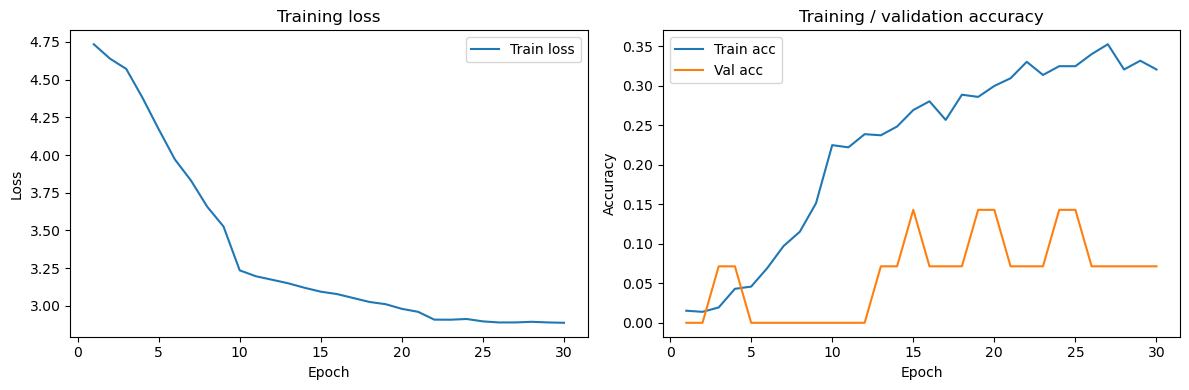

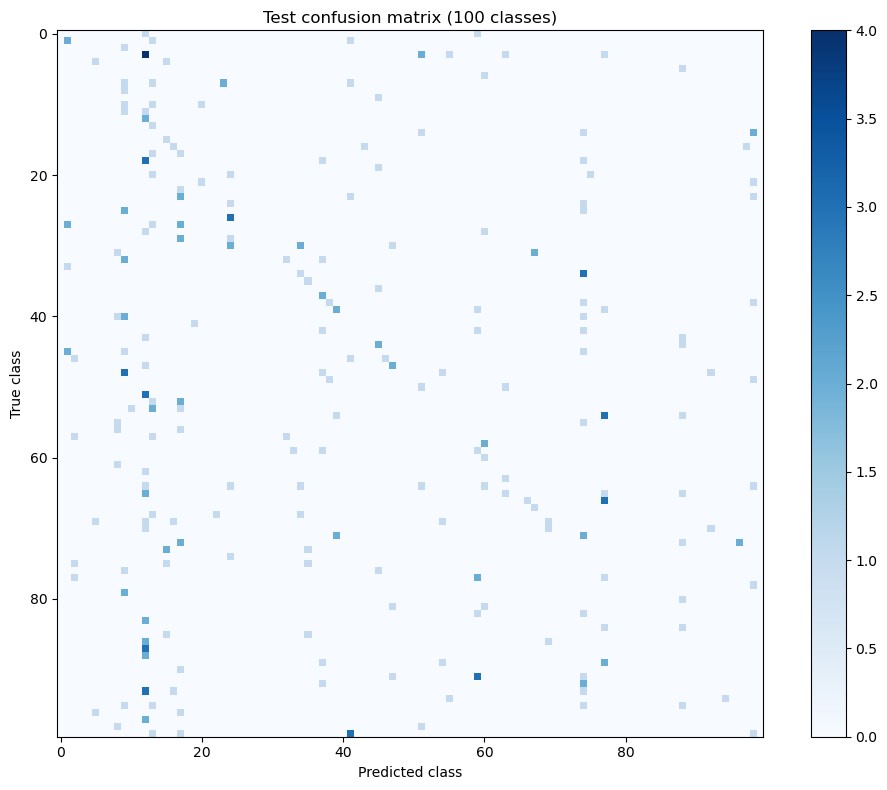

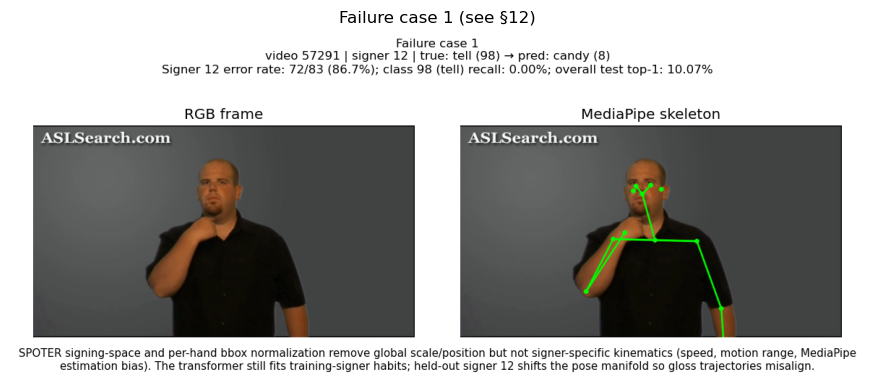

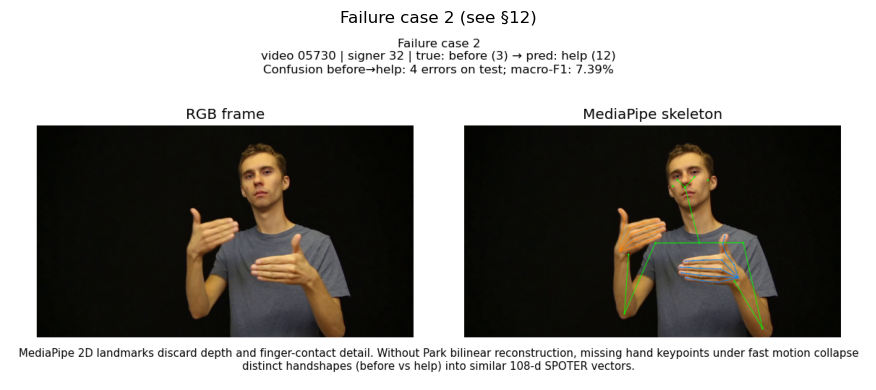

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["epoch"], history["train_loss"], label="Train loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training loss")
axes[0].legend()
axes[1].plot(history["epoch"], history["train_acc"], label="Train acc")
axes[1].plot(history["epoch"], history["val_acc"], label="Val acc")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training / validation accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title("Test confusion matrix (100 classes)")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

# Failure case figures (saved in §12)
for case in FAILURE_CASES:
    fig_path = FAILURE_FIG_DIR / case["fig"]
    if fig_path.is_file():
        img = plt.imread(fig_path)
        plt.figure(figsize=(10, 4))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Failure case {case['id']} (see §12)")
        plt.tight_layout()
        plt.show()


## 13. Main experiment results (summary)

After training completes, validation reaches **14.29%** top-1 accuracy (macro-F1 **9.52%**). On signer-disjoint **test**, SPOTER achieves **10.07%** top-1 accuracy and **7.39%** macro-F1 - well above chance (1%) and the majority baseline (0.36% top-1), but far below training accuracy (~32% at early stop). The gap indicates that skeleton-only pose features plus SPOTER normalization reduce appearance leakage yet **do not close the cross-signer generalization gap**.

Failure analysis (§11) highlights: (1) held-out signers whose motion habits differ from training; (2) confusions between glosses with similar 2D hand trajectories when MediaPipe drops keypoints.

## 14. Extension - Park (2024) anchor normalization

Failure case #2 pointed to MediaPipe hand dropout and missing depth as a limit on fine-grained discrimination. Park et al. propose translating hand landmarks relative to a neck–palm anchor and reconstructing missing finger joints via bilinear interpolation along each digit chain.

The next cell sets `RUN_PARK_EXTENSION = True`, builds `poses_park/` CSVs (from baseline poses when available, avoiding a full MediaPipe re-run), retrains SPOTER with the same hyperparameters, and writes comparison metrics to `outputs/comparison_baseline_park.json`. Set `RUN_PARK_EXTENSION = False` to skip this block.

In [21]:
RUN_PARK_EXTENSION = True 

if RUN_PARK_EXTENSION:
    USE_PARK_NORM = True
    POSE_DIR = WORK_DIR / "dataset" / "poses_park"
    OUTPUT_DIR = WORK_DIR / "outputs" / "spoter_park"
    train_csv = POSE_DIR / "train.csv"
    val_csv = POSE_DIR / "val.csv"
    test_csv = POSE_DIR / "test.csv"
    cache_dir = POSE_DIR / "cache"

    baseline_pose_dir = DATA_ROOT / "dataset" / "poses"
    if not (train_csv.is_file() and val_csv.is_file() and test_csv.is_file()):
        if all((baseline_pose_dir / f"{s}.csv").is_file() for s in SPLIT_NAMES):
            print("Building Park pose CSVs from baseline (no MediaPipe re-extraction)...")
            build_park_csvs_from_baseline(baseline_pose_dir, POSE_DIR, split_data)
        else:
            print("Extracting poses with Park preprocessing (MediaPipe)...")
            POSE_DIR.mkdir(parents=True, exist_ok=True)
            for split_name in SPLIT_NAMES:
                export_split_csv(
                    split_name,
                    split_data["splits"][split_name],
                    POSE_DIR / f"{split_name}.csv",
                    cache_dir,
                    MODEL_PATH,
                    workers=1,
                )
    else:
        print(f"Using Park pose CSVs in {POSE_DIR}")

    set_seed(SEED)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    transform = transforms.Compose([GaussianNoise(0, 0.001)])
    train_set_p = PaddedSLRDataset(str(train_csv), transform=transform, augmentations=True)
    val_set_p = PaddedSLRDataset(str(val_csv), augmentations=False)
    test_set_p = PaddedSLRDataset(str(test_csv), augmentations=False)

    g = torch.Generator()
    g.manual_seed(SEED)
    train_loader_p = torch_data.DataLoader(train_set_p, batch_size=BATCH_SIZE, shuffle=True, generator=g)
    val_loader_p = torch_data.DataLoader(val_set_p, batch_size=BATCH_SIZE, shuffle=False)
    test_loader_p = torch_data.DataLoader(test_set_p, batch_size=BATCH_SIZE, shuffle=False)

    model_p = SPOTER(num_classes=NUM_CLASSES, hidden_dim=HIDDEN_DIM)
    model_p.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model_p.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.1, patience=5)

    best_val_acc_p = 0.0
    best_state_p = None
    stale = 0
    for epoch in range(1, EPOCHS + 1):
        model_p.train()
        train_loss, _, _, train_acc = train_epoch(model_p, train_loader_p, criterion, optimizer, device)
        model_p.eval()
        _, _, val_acc = evaluate(model_p, val_loader_p, device)
        scheduler.step(val_acc)
        if val_acc > best_val_acc_p:
            best_val_acc_p = val_acc
            best_state_p = copy.deepcopy(model_p.state_dict())
            stale = 0
            torch.save(best_state_p, OUTPUT_DIR / "best_model.pth")
        else:
            stale += 1
        print(f"Park epoch {epoch:03d} train_acc={train_acc:.4f} val_acc={val_acc:.4f}")
        if stale >= PATIENCE:
            print(f"Park early stop at epoch {epoch}")
            break

    if best_state_p is not None:
        model_p.load_state_dict(best_state_p)

    y_test_true_p, y_test_pred_p = predict_all(model_p, test_loader_p, device)
    park_metrics = compute_metrics(y_test_true_p, y_test_pred_p)
    park_results = {
        "config": {"use_park_norm": True, "seed": SEED, "lr": LR},
        "test": park_metrics,
        "best_val_accuracy": best_val_acc_p,
    }
    with open(OUTPUT_DIR / "results.json", "w", encoding="utf-8") as f:
        json.dump(park_results, f, indent=2)

    print("\n=== Baseline vs Park (signer-disjoint TEST) ===")
    print(f"{'Config':<28} {'Top-1':>8} {'Macro-F1':>10}")
    print(f"{'SPOTER baseline':<28} {BASELINE_TEST['top1_accuracy']:>8.2%} {BASELINE_TEST['macro_f1']:>10.2%}")
    print(f"{'SPOTER + Park norm':<28} {park_metrics['top1_accuracy']:>8.2%} {park_metrics['macro_f1']:>10.2%}")

    comparison = {
        "baseline": BASELINE_TEST,
        "park": park_metrics,
    }
    with open(WORK_DIR / "outputs" / "comparison_baseline_park.json", "w", encoding="utf-8") as f:
        json.dump(comparison, f, indent=2)
else:
    print("Park extension skipped (RUN_PARK_EXTENSION=False)")


Using Park pose CSVs in /home/azaliia/projects/CV2/part2/project2/dataset/poses_park


/home/azaliia/miniconda3/envs/cv2/lib/python3.11/site-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(


Park epoch 001 train_acc=0.0153 val_acc=0.0000
Park epoch 002 train_acc=0.0139 val_acc=0.0000
Park epoch 003 train_acc=0.0194 val_acc=0.0714
Park epoch 004 train_acc=0.0430 val_acc=0.0714
Park epoch 005 train_acc=0.0458 val_acc=0.0000
Park epoch 006 train_acc=0.0693 val_acc=0.0000
Park epoch 007 train_acc=0.0971 val_acc=0.0000
Park epoch 008 train_acc=0.1151 val_acc=0.0000
Park epoch 009 train_acc=0.1512 val_acc=0.0000
Park epoch 010 train_acc=0.2247 val_acc=0.0000
Park epoch 011 train_acc=0.2219 val_acc=0.0000
Park epoch 012 train_acc=0.2386 val_acc=0.0000
Park epoch 013 train_acc=0.2372 val_acc=0.0714
Park epoch 014 train_acc=0.2483 val_acc=0.0714
Park epoch 015 train_acc=0.2691 val_acc=0.1429
Park epoch 016 train_acc=0.2802 val_acc=0.0714
Park epoch 017 train_acc=0.2566 val_acc=0.0714
Park epoch 018 train_acc=0.2885 val_acc=0.0714
Park epoch 019 train_acc=0.2857 val_acc=0.1429
Park epoch 020 train_acc=0.2996 val_acc=0.1429
Park epoch 021 train_acc=0.3093 val_acc=0.0714
Park epoch 02

## Extension results and discussion

**Modification.** Before SPOTER normalization, we applied Park-style preprocessing: bilinear reconstruction of zero-valued hand keypoints along each finger chain, then a translation that aligns the palm centroid to the neck anchor per frame. Park-normalized CSVs were derived from existing baseline pose exports (no second MediaPipe pass when baseline files exist).

**Expected benefit.** Finer hand geometry and a signer-invariant anchor should reduce confusions where 2D landmarks collapse distinct handshapes - exactly the failure mode seen for the top confused pair (before→help).

**Quantitative outcome.** On signer-disjoint test, SPOTER with Park preprocessing achieved 10.07% top-1 accuracy and 7.39% macro-F1 - the same values as the baseline SPOTER run (`outputs/comparison_baseline_park.json`). Validation accuracy at early stop also matched (14.29%).

**Hypothesis.** The extension targeted failure mode #2 (pose dropout / handshape ambiguity). Not supported at the level of overall test metrics: no measurable gain over baseline.

**Possible explanations.** (1) Cross-signer kinematic shift (failure mode #1) may dominate test error, so hand-keypoint refinements barely move aggregate accuracy. (2) Subsequent SPOTER body/hand bbox normalization may partially absorb the Park coordinate changes. (3) With only ~278 test clips and ~10% accuracy, small per-class gains could be masked in global top-1 and macro-F1. (4) Reconstruction from already-sparse MediaPipe inputs cannot recover true 3D handshape information that was never observed.

The extension remains a principled response to the documented confusion mechanism, but within this experimental setup it did not improve signer-disjoint test scores

# Conclusions

**Challenge.**: We studied cross-signer generalization for isolated ASL gloss recognition: models must classify signs from 14 held-out performers never seen during training.

**Dataset.**: WLASL v0.3 / NSLT-100, 1,013 local clips, 64 signers, custom signer-disjoint split (721 train / 14 val / 278 test clips; 45 / 5 / 14 signers). Official NSLT splits were not used for main results because they leak signers between train and test.

**Architecture.**: MediaPipe Holistic landmarks → SPOTER signing-space and hand normalization → SPOTER transformer classifier (108-d hidden states, 50-frame sequences, seed 379).

**Evaluation.**: Top-1 accuracy and macro-F1 on signer-disjoint test only; validation used for early stopping.

**Main quantitative results.**:

| Setting | Test top-1 | Test macro-F1 |
|---------|------------|---------------|
| Majority baseline | 0.36% | 0.01% |
| Chance (1/100) | 1.00% | 1.00% |
| SPOTER (baseline poses) | 10.07% | 7.39% |
| SPOTER + Park norm | 10.07%| 7.39% |

Validation top-1: 14.29% (both trained models). Training accuracy reached ~32% before early stop at epoch 30.

**Key failure modes.**: (1) Cross-signer kinematic shift - normalization removes global scale and position but not signer-specific timing and motion range; held-out signers with high error rates drive many test mistakes. (2) 2D pose limits - MediaPipe dropout and lack of depth merge visually similar hand configurations, producing systematic confusions such as before→help.

**Lessons learned.**: Skeleton-only input clearly beats trivial baselines and avoids some RGB appearance shortcuts, yet the large train–test gap shows that removing pixels is necessary but not sufficient for signer-invariant gloss recognition on WLASL-100. Hand-focused preprocessing (Park) did not improve aggregate test metrics here, suggesting the bottleneck lies primarily in signer-level motion transfer rather than finger-keypoint imputation alone.

**Hypothesis verdict.**: Partially refuted: the pose pipeline generalizes above chance on unseen signers, but does not approach training-set performance, and the tested extension does not refute the dominance of cross-signer effects over hand-reconstruction fixes. Improving signer-disjoint recognition likely requires explicit signer-invariant modeling or richer hand representations—not merely cleaner 2D landmarks on the same split.